# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [57]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


Não foram identificados dados nulos, e as variáveis já se encontram com os tipos adequados. A exceção é a variável Gender, que ainda será ajustada na próxima etapa.

In [58]:
#SEU CÓDIGO AQUI
df = pd.read_csv('CARRO_CLIENTES.csv', delimiter=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [59]:
df = df.drop(columns=['User ID'])

In [60]:
df

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0
...,...,...,...,...
995,Male,38,59000,0
996,Female,47,23500,0
997,Female,28,138500,1
998,Female,48,134000,1


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [38]:
#SEU CÓDIGO AQUI
label_encoder = LabelEncoder()
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])

In [39]:
df = df.drop(columns=['Gender'])

In [40]:
df

,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1
...,...,...,...,...
995,38,59000,0,1
996,47,23500,0,0
997,28,138500,1,0
998,48,134000,1,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

A variável que apresenta maior correlação com a variável principal Purchased é Age, com coeficiente de 0,62. Em seguida, destaca-se a variável AnnualSalary, com correlação de 0,36.

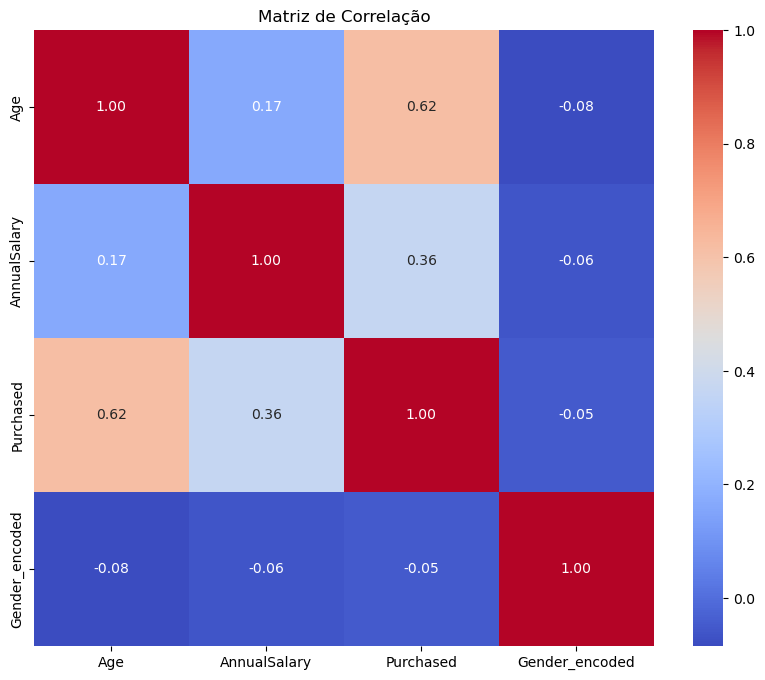

In [41]:
#SEU CÓDIGO AQUI
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [42]:
#SEU CÓDIGO AQUI
X = df.drop(columns=['Purchased'])
Y = df['Purchased']

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [44]:
#SEU CÓDIGO AQUI
model_xgboost = xgb.XGBClassifier()
model_xgboost.objective

'binary:logistic'

In [45]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [48]:
model_xgboost = xgb.XGBClassifier( max_depth=4, n_estimators=100).fit(X_train, Y_train)

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [49]:
#SEU CÓDIGO AQUI
Y_pred = model_xgboost.predict(X_test)  
Y_pred_prob = model_xgboost.predict_proba(X_test) 

In [50]:
Y_pred_prob

array([[8.10223162e-01, 1.89776823e-01],
       [1.59637451e-01, 8.40362549e-01],
       [9.99940038e-01, 5.99527266e-05],
       [8.87831390e-01, 1.12168618e-01],
       [1.99679077e-01, 8.00320923e-01],
       [1.29134655e-02, 9.87086535e-01],
       [3.31521034e-04, 9.99668479e-01],
       [9.99849141e-01, 1.50872525e-04],
       [9.99461830e-01, 5.38156368e-04],
       [9.97095168e-01, 2.90483516e-03],
       [9.73258615e-01, 2.67414004e-02],
       [9.99939442e-01, 6.05793794e-05],
       [9.53331530e-01, 4.66684736e-02],
       [9.99671519e-01, 3.28474009e-04],
       [1.21296048e-02, 9.87870395e-01],
       [6.26291037e-02, 9.37370896e-01],
       [6.47485316e-01, 3.52514684e-01],
       [1.53034925e-01, 8.46965075e-01],
       [3.06839943e-02, 9.69316006e-01],
       [9.99792218e-01, 2.07771125e-04],
       [9.99084115e-01, 9.15858953e-04],
       [3.54224443e-03, 9.96457756e-01],
       [8.70043039e-03, 9.91299570e-01],
       [9.99950171e-01, 4.98007539e-05],
       [8.893430

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

O modelo XGBoost apresentou uma acurácia de 89% e precisão de 89% em ambas as classes. Observa-se que, para a classe 0, o desempenho foi superior, com recall de 92% e F1-score de 90%. Já para a classe 1, o modelo obteve recall de 85% e F1-score de 87%. Entretanto, como os dados estão desbalanceados, ainda é válido realizar novos testes com técnicas de balanceamento, buscando melhorar principalmente o desempenho na classe minoritária.

In [54]:
#SEU CÓDIGO AQUI
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.89
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       112
           1       0.89      0.85      0.87        88

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200

Matriz de Confusão:
[[103   9]
 [ 13  75]]


# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

Sim, a variável que apresenta maior relação com a variável principal Purchased continua sendo Age, com importância de 3,22. Em seguida, destaca-se a variável AnnualSalary, com importância de 1,86.

In [56]:
#SEU CÓDIGO AQUI
importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para um DataFrame
importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

          Feature  Importance
0             Age    3.216005
1    AnnualSalary    1.861657
2  Gender_encoded    0.720675
